# Content and Objective

+ Show some examples for the Hilbert transform

# Importing and Plotting Options

In [1]:
import numpy as np

from scipy import signal
from time import time 

import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# plotting options 
font = {'size'   : 20}
plt.rc('font', **font)
plt.rc('text', usetex=0)

matplotlib.rc('figure', figsize=(12, 4) )

# Construct finite approximation of the impulse response and show frequency response

In [3]:
# length of Hilbert imulse response
# symmetrical around zero --> choose an odd number here
N = 65

n_array = np.arange( - (N-1)//2, (N-1)//2+1 )

h_Hilbert = np.array( [ 2 / ( np.pi * k ) if k%2 == 1 else 0 for k in n_array ] )

In [4]:
# now get the frequency response 
# mind the fact that we "artificially" shifted the impulse response and, thus,
# have to shift the signal before applying FFT
# -> just use the second option wo. shifting and see what happens

H_Hilbert = np.fft.fft( np.roll( h_Hilbert, (N-1)//2 +1 ) )
#H_Hilbert = np.fft.fft( h_Hilbert, (N-1)//2 +1 )

Omega_array = np.linspace( -np.pi, np.pi, len( H_Hilbert ) )

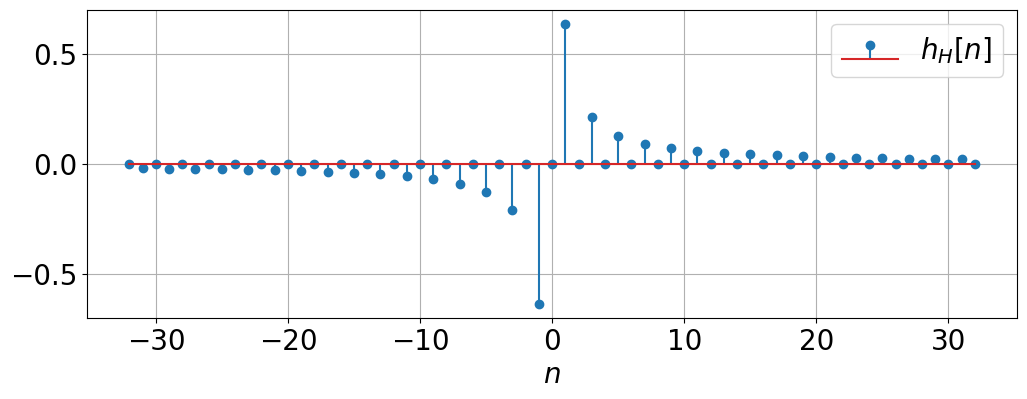

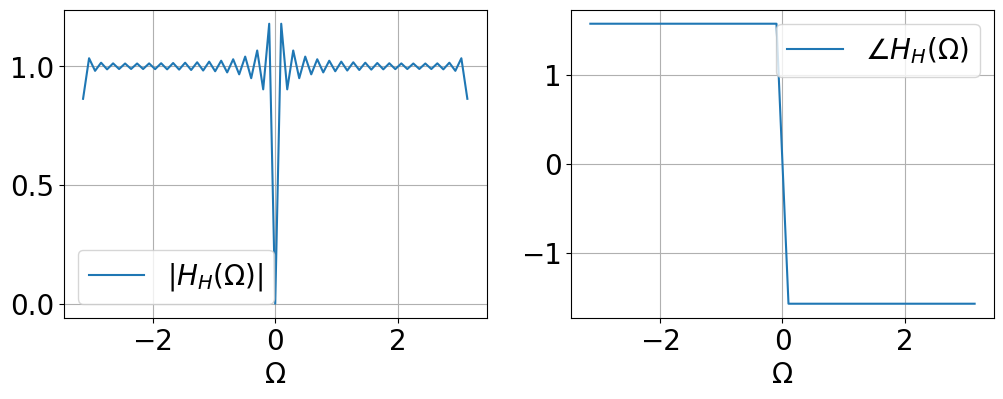

In [5]:
plt.figure()
plt.stem( n_array, h_Hilbert, label='$h_H[n]$' )
plt.xlabel('$n$')
plt.grid(1)
plt.legend()

plt.figure()
plt.subplot(121)
plt.plot( Omega_array, np.fft.fftshift( np.abs( H_Hilbert) ), label='$|H_H(\\Omega)|$')
plt.xlabel('$\\Omega$')
plt.grid(1)
plt.legend()

plt.subplot(122)
plt.plot( Omega_array, np.fft.fftshift( np.angle( H_Hilbert) ), label='$\\angle H_H(\\Omega)$')
plt.xlabel('$\\Omega$')
plt.grid(1)
plt.legend()

plt.show()

# Hilbert transform of cosine

In [6]:
# define cosine
t_s = 0.01
T = 2
t_array = np.arange( 0, T, t_s )

f_0 = 5
x = np.cos( 2 * np.pi * f_0 * t_array  )

# find its Hilbert transform

# you should really play with the mode-options:
# check full and valid and see what happens later...
chosen_mode = 'same'

x_Hilbert = np.convolve( x, h_Hilbert, mode = chosen_mode )
x_Hilbert *= ( np.linalg.norm( x ) / np.linalg.norm( x_Hilbert ) )

# note that convolution possibly increases length,
# thus, we have to adapt the "x-values",
# depending on the mode-option chosen before
N_Hilbert = len( x_Hilbert )
n_array_Hilbert = np.arange( - (N_Hilbert-1)//2, (N_Hilbert-1)//2+1 ) 
t_array_Hilbert = n_array_Hilbert * t_s

In [7]:
# now get the frequency response of the Hilbert transformed signal
X_Hilbert = np.fft.fft( x_Hilbert )

Omega_array_Hilbert = np.linspace( -np.pi, np.pi, len( X_Hilbert ) )

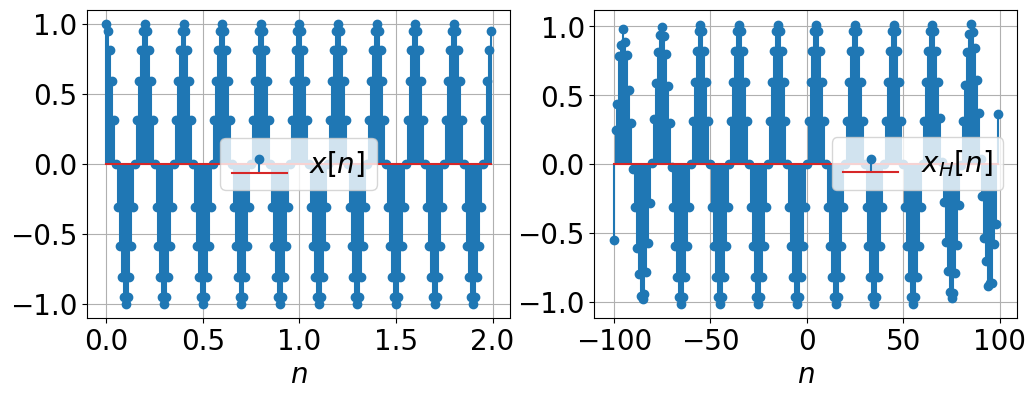

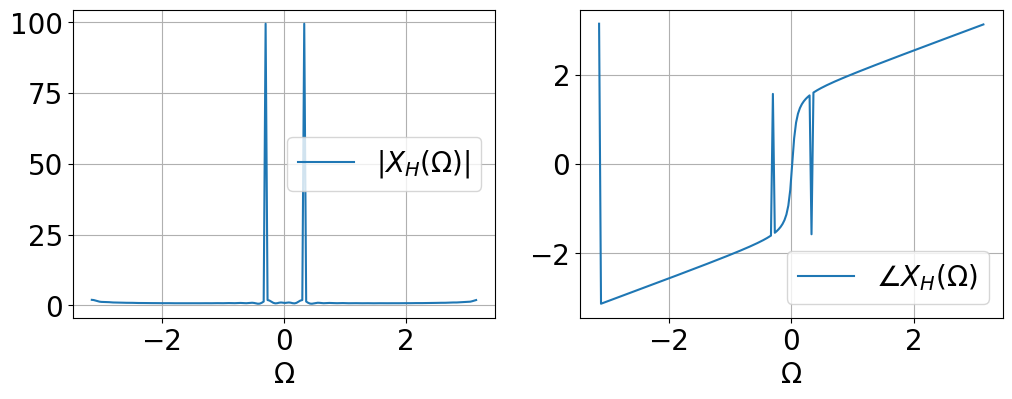

In [8]:
plt.figure()

plt.subplot(121)
plt.stem( t_array, x, label='$x[n]$' )
plt.xlabel('$n$')
plt.grid(1)
plt.legend()

plt.subplot(122)
plt.stem( n_array_Hilbert, x_Hilbert, label='$x_H[n]$' )
plt.xlabel('$n$')
plt.grid(1)
plt.legend()

plt.figure()
plt.subplot(121)
plt.plot( Omega_array_Hilbert, np.fft.fftshift( np.abs( X_Hilbert) ), label='$|X_H(\\Omega)|$')
plt.xlabel('$\\Omega$')
plt.grid(1)
plt.legend()

plt.subplot(122)
plt.plot( Omega_array_Hilbert, np.fft.fftshift( np.angle( X_Hilbert) ), label='$\\angle X_H(\\Omega)$')
plt.xlabel('$\\Omega$')
plt.grid(1)
plt.legend()

# Now get the analytical signal and its frequency response

In [9]:
# define analytical signal
# depending on the mode-option you would need to adapt the sliced part of the signal
x_analytical = x + 1j * x_Hilbert

# Fourier regime
X_analytical = np.fft.fft( x_analytical )

# find respective arrays for x-values in time and frequency if necessary
N_analytical = len( x_analytical )

n_array_analytical = np.arange( - (N_analytical-1)//2, (N_analytical-1)//2+1 )
Omega_array_analytical = np.linspace( -np.pi, np.pi, len( X_analytical ) )

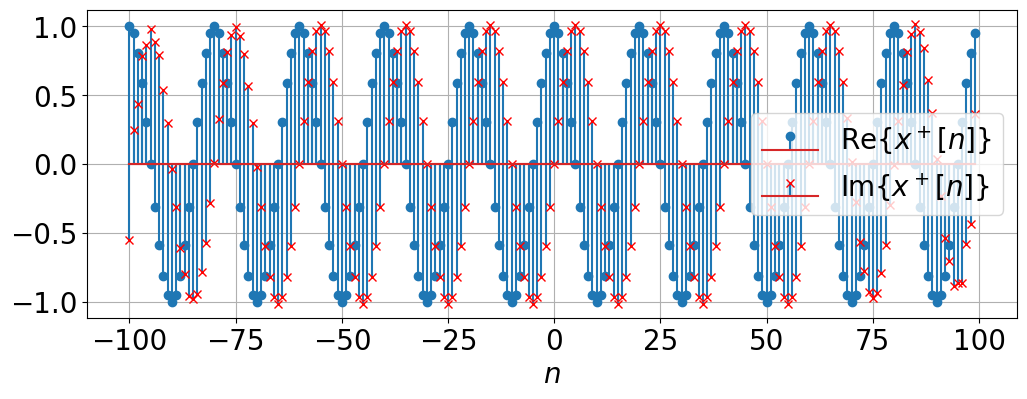

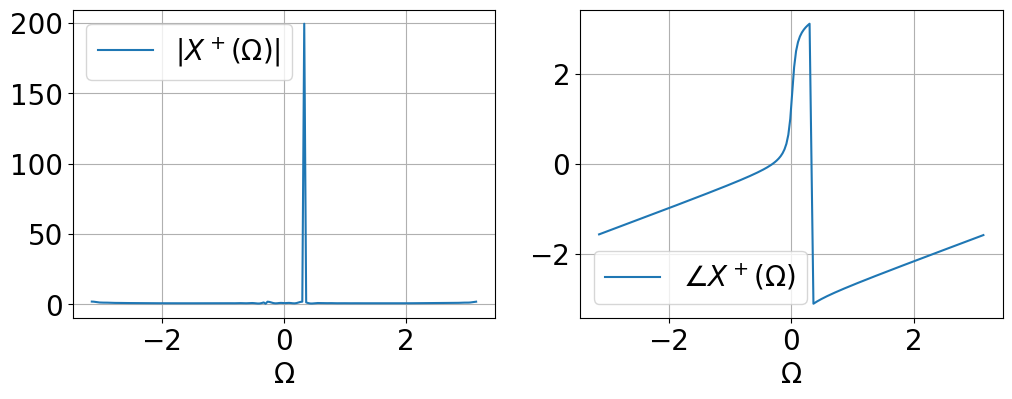

In [10]:
plt.figure()
plt.stem( n_array_analytical, np.real( x_analytical ), label='$\\mathrm{Re}\\{x^+[n]\\}$' )
plt.stem( n_array_analytical, np.imag( x_analytical ), markerfmt='rx', label='$\\mathrm{Im}\\{x^+[n]\\}$' )
plt.xlabel('$n$')
plt.grid(1)
plt.legend()

plt.figure()
plt.subplot(121)
plt.plot( Omega_array_analytical, np.fft.fftshift( np.abs( X_analytical ) ), label='$|X^+(\\Omega)|$')
plt.xlabel('$\\Omega$')
plt.grid(1)
plt.legend()

plt.subplot(122)
plt.plot( Omega_array_analytical, np.fft.fftshift( np.angle( X_analytical) ), label='$\\angle X^+(\\Omega)$')
plt.xlabel('$\\Omega$')
plt.grid(1)
plt.legend()